In [ ]:
from tests.steady_state_solver.systems import build_two_modes, build_random_single_mode, build_kerr_oscillator
import dynamiqs as dq 
import jax
import time
import matplotlib.pyplot as plt
from jax import Array
from typing import Any
import jax.numpy as jnp

jax.config.update('jax_enable_x64',True)

na_list=[8,16,24,32,40]
k_size = [16,32,64]


def runtime_vs_dim( na_list: Array,
                    k_size: Array,
                    build_fn: Any,
                    title:str="Runtime vs dimension", 
                    precond_side: str="left")->Any:
    plt.figure()
    
    print('--'*20)
    print(f"Preconditioner side: {precond_side}")
    print('--'*20)

    for ks in k_size:
        runtime = []
        dims = []
        print('=='*20)
        print(f"krylov size = {ks}")
        print('=='*20)
        for na in na_list: 
            nb=na//3
            dim = na*nb
            H,Ls = build_fn(na,nb)
            
    
        
            solver = dq.SteadyStateGMRES( tol= 1e-8,
                                          krylov_size=ks,
                                          preconditioner_side=precond_side,
                                          max_iteration=10)
            res_warmup = dq.steadystate(H,Ls,solver=solver)
            res_warmup.rho.block_until_ready()

            t0=time.perf_counter()
            res = dq.steadystate(H,Ls,solver=solver)
            res.rho.block_until_ready()
            t1 = time.perf_counter()
            t = t1-t0
            norminf= jnp.max(jnp.abs(dq.lindbladian(H,Ls,res.rho).to_jax()))
            print(f'na={na}, ||L(rho)||_inf={norminf:.2e}')
            runtime.append(t)
            dims.append(dim)

        plt.loglog(dims, runtime, marker='o', linestyle='-', label=f'krylov size = {ks}')
    
    plt.legend()
    plt.title(title)





----------------------------------------
Preconditioner side: left
----------------------------------------
krylov size = 16
na=8, ||L(rho)||_inf=3.99e-12
na=16, ||L(rho)||_inf=3.46e-10
na=24, ||L(rho)||_inf=2.67e-09
na=32, ||L(rho)||_inf=2.66e-08
na=40, ||L(rho)||_inf=1.07e-09
krylov size = 32
na=8, ||L(rho)||_inf=2.84e-13
na=16, ||L(rho)||_inf=9.66e-13
na=24, ||L(rho)||_inf=1.74e-11
na=32, ||L(rho)||_inf=1.94e-10
na=40, ||L(rho)||_inf=1.08e-09
krylov size = 64
na=8, ||L(rho)||_inf=1.15e-15
na=16, ||L(rho)||_inf=4.87e-13
na=24, ||L(rho)||_inf=1.58e-11
na=32, ||L(rho)||_inf=2.00e-10
na=40, ||L(rho)||_inf=1.08e-09
----------------------------------------
Preconditioner side: right
----------------------------------------
krylov size = 16
na=8, ||L(rho)||_inf=3.43e-12
na=16, ||L(rho)||_inf=6.38e-11
na=24, ||L(rho)||_inf=4.89e-10
na=32, ||L(rho)||_inf=1.85e-09
na=40, ||L(rho)||_inf=5.68e-11
krylov size = 32
na=8, ||L(rho)||_inf=8.33e-14
na=16, ||L(rho)||_inf=1.63e-13
na=24, ||L(rho)||_inf

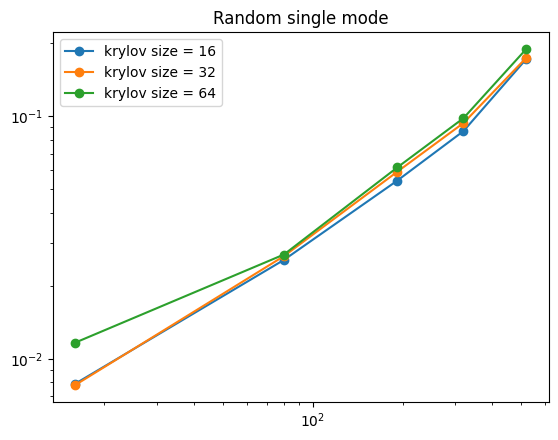

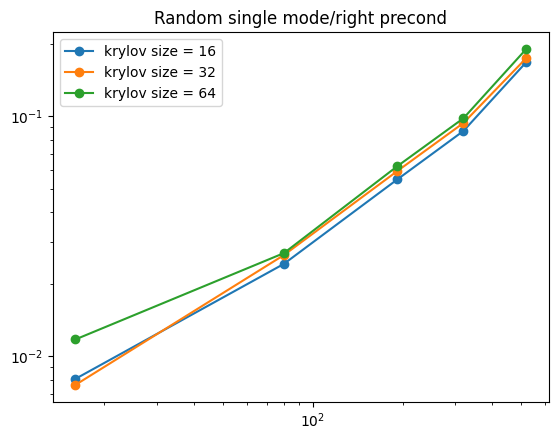

In [10]:
runtime_vs_dim(na_list,k_size,lambda na,nb: build_random_single_mode(na*nb),title = "Random single mode")
runtime_vs_dim(na_list,k_size,lambda na,nb: build_random_single_mode(na*nb),title = "Random single mode/right precond", precond_side='right')


----------------------------------------
Preconditioner side: left
----------------------------------------
krylov size = 16
na=8, ||L(rho)||_inf=2.05e-17
na=16, ||L(rho)||_inf=8.16e-11
na=24, ||L(rho)||_inf=3.04e-10
na=32, ||L(rho)||_inf=5.80e-09
na=40, ||L(rho)||_inf=2.82e-09
krylov size = 32
na=8, ||L(rho)||_inf=1.59e-17
na=16, ||L(rho)||_inf=2.50e-16
na=24, ||L(rho)||_inf=1.73e-14
na=32, ||L(rho)||_inf=1.93e-10
na=40, ||L(rho)||_inf=4.86e-10
krylov size = 64
na=8, ||L(rho)||_inf=1.59e-17
na=16, ||L(rho)||_inf=3.36e-16
na=24, ||L(rho)||_inf=7.29e-16
na=32, ||L(rho)||_inf=1.67e-15
na=40, ||L(rho)||_inf=1.58e-13
----------------------------------------
Preconditioner side: right
----------------------------------------
krylov size = 16
na=8, ||L(rho)||_inf=3.45e-15
na=16, ||L(rho)||_inf=6.26e-10
na=24, ||L(rho)||_inf=2.40e-08
na=32, ||L(rho)||_inf=5.36e-09
na=40, ||L(rho)||_inf=4.49e-09
krylov size = 32
na=8, ||L(rho)||_inf=1.90e-15
na=16, ||L(rho)||_inf=4.31e-15
na=24, ||L(rho)||_inf

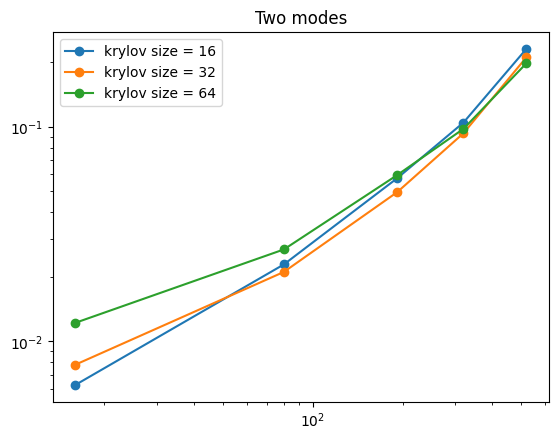

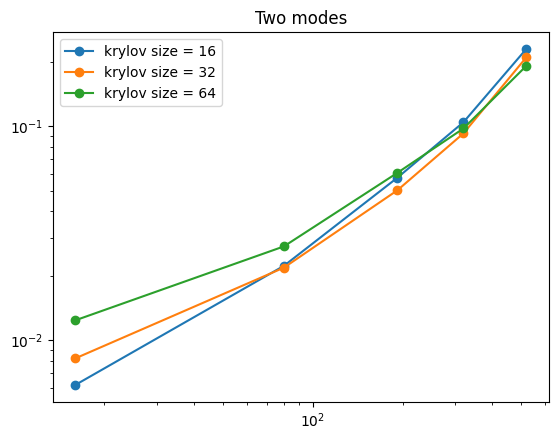

In [11]:
runtime_vs_dim(na_list,k_size,lambda na,nb: build_two_modes(na,nb,kappa_a=1.0),title = "Two modes")
runtime_vs_dim(na_list,k_size,lambda na,nb: build_two_modes(na,nb,kappa_a=1.0),title = "Two modes",precond_side='right')

In [ ]:
na_list=[40] 
k_size = [128,256]
runtime_vs_dim(na_list,k_size,lambda na,nb: build_kerr_oscillator(na*nb),title = "Kerr oscillator")
runtime_vs_dim(na_list,k_size,lambda na,nb: build_kerr_oscillator(na*nb),title = "Kerr oscillator",precond_side='right')

----------------------------------------
Preconditioner side: left
----------------------------------------
krylov size = 128


In [5]:
def build_G(H, jump_ops, gamma: float = 1.0):
    H = H.to_jax()
    G = -1j * H
    for Lk in jump_ops:
        Lk = Lk.to_jax()
        G -= 0.5 * gamma * (Lk.conj().T @ Lk)
    return G
def print_smallest_eigenvalues_G(
    H=None, Ls=None, na: int = 0, nb: int = None, gamma: float = 1.0,
    k: int = 10, build_fn: Any = None, prec: int = 6,
):
    """
    Print the k smallest eigenvalues of G in a formatted table.
    """
    if nb is None:
        nb = na // 3
    dim = na * nb

    if H is None or Ls is None:
       H,Ls= build_fn(na,nb)

    G = build_G(H, Ls, gamma=gamma)
    eigvals = jnp.array(jnp.linalg.eigvals(G))

    kk = min(k, eigvals.size)
    idx = jnp.argsort(jnp.abs(eigvals))[:kk]
    
    modules = jnp.abs(eigvals)
    
    print(f"\n{kk} valeurs propres de G de plus petit module :")
    print(" idx |        Re(λ)        Im(λ)        |λ|")
    print("-" * 55)
    
    for i, k_idx in enumerate(idx):
        ev = eigvals[k_idx]
        print(
            f"{i:4d} | "
            f"{ev.real: .{prec}e}  "
            f"{ev.imag: .{prec}e}  "
            f"{modules[k_idx]: .{prec}e}"
        )

In [8]:
na = 6
nb= na//3
H,Ls= build_kerr_oscillator(na*nb)
print_smallest_eigenvalues_G(H,Ls)


10 valeurs propres de G de plus petit module :
 idx |        Re(λ)        Im(λ)        |λ|
-------------------------------------------------------
   0 | -1.569706e+02  -5.556494e+00   1.570689e+02
   1 | -1.658579e+02   1.178678e+02   2.034740e+02
   2 | -1.615294e+02  -1.293010e+02   2.069070e+02
   3 | -1.861168e+02   2.425049e+02   3.056928e+02
   4 | -1.820258e+02  -2.587619e+02   3.163718e+02
   5 | -2.177174e+02   3.676117e+02   4.272461e+02
   6 | -2.183363e+02  -4.024973e+02   4.579026e+02
   7 | -2.634642e+02   4.900326e+02   5.563680e+02
   8 | -2.685921e+02  -5.701357e+02   6.302352e+02
   9 | -3.347185e+02   5.952095e+02   6.828695e+02


In [7]:
import jax.numpy as jnp
import dynamiqs as dq


def build_G(H, jump_ops):
    H = H.to_jax() if hasattr(H, "to_jax") else H
    G = -1j * H
    for Lk in jump_ops:
        Lk = Lk.to_jax() if hasattr(Lk, "to_jax") else Lk
        G -= 0.5 * Lk.conj().T @ Lk
    return G


def smallest_eig_real_parts(G, k=10):
    eigvals = jnp.linalg.eigvals(G)
    idx = jnp.argsort(jnp.abs(eigvals.real))[:k]
    return eigvals[idx].real

def print_smallest_eigs_for_all_deltas_benchmark(
    N=40, n_detunings=3, delta_min=-20.0, delta_max=20.0, k=10, prec=6
):
    twopi = 2.0 * jnp.pi
    kappa, kerr, eps = 14.0 * twopi, -1.0 * twopi, 16.0

    a = dq.destroy(N).to_jax()
    ad = a.conj().T

    delta_vals = jnp.linspace(delta_min, delta_max, n_detunings) * twopi

    for d in delta_vals.tolist():
        H = -kerr/2 * ad @ ad @ a @ a - d * ad @ a + 1j*jnp.sqrt(kappa)*eps*(a - ad)
        L = jnp.sqrt(kappa) * a
        G = build_G(H, [L])
        reals = smallest_eig_real_parts(G, k)

        print(f"\nδ = {d/twopi:+.4f}·2π")
        for i, r in enumerate(reals.tolist()):
            print(f"  {i}: Re(λ) = {r: .{prec}e}")

In [9]:
print_smallest_eigs_for_all_deltas_benchmark(N=40, n_detunings=10, delta_min=-2, delta_max=2, k=4, prec=6)


δ = -2.0000·2π
  0: Re(λ) = -3.034214e+02
  1: Re(λ) = -3.035304e+02
  2: Re(λ) = -3.043595e+02
  3: Re(λ) = -3.060072e+02

δ = -1.5556·2π
  0: Re(λ) = -3.157539e+02
  1: Re(λ) = -3.158775e+02
  2: Re(λ) = -3.161703e+02
  3: Re(λ) = -3.168199e+02

δ = -1.1111·2π
  0: Re(λ) = -3.278518e+02
  1: Re(λ) = -3.279760e+02
  2: Re(λ) = -3.282710e+02
  3: Re(λ) = -3.288179e+02

δ = -0.6667·2π
  0: Re(λ) = -3.396012e+02
  1: Re(λ) = -3.398020e+02
  2: Re(λ) = -3.401236e+02
  3: Re(λ) = -3.408011e+02

δ = -0.2222·2π
  0: Re(λ) = -3.505047e+02
  1: Re(λ) = -3.511043e+02
  2: Re(λ) = -3.515701e+02
  3: Re(λ) = -3.515817e+02

δ = +0.2222·2π
  0: Re(λ) = -3.594965e+02
  1: Re(λ) = -3.610430e+02
  2: Re(λ) = -3.631206e+02
  3: Re(λ) = -3.632217e+02

δ = +0.6667·2π
  0: Re(λ) = -3.525799e+02
  1: Re(λ) = -3.721924e+02
  2: Re(λ) = -3.724939e+02
  3: Re(λ) = -3.728789e+02

δ = +1.1111·2π
  0: Re(λ) = -3.527754e+02
  1: Re(λ) = -3.703903e+02
  2: Re(λ) = -3.814114e+02
  3: Re(λ) = -3.850258e+02

δ = +1.